# E-commerce Sales Analytics — Python EDA

## Project Overview

This project performs Exploratory Data Analysis (EDA) on an e-commerce sales dataset containing 1,800 orders.

The objective is to analyze sales, profit, products, categories, customers, cities, payment methods, order status and monthly trends to identify meaningful business insights.

### Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Key Analysis
- Data cleaning and validation
- Descriptive statistics
- Category analysis
- Product analysis
- Sales and profit analysis
- Outlier detection using IQR
- Monthly sales and profit trends
- Order status analysis
- Payment method analysis
- City-wise analysis
- Customer analysis
- Correlation analysis
- Business insights

## Dataset Summary

- Total Orders: 1,800
- Total Quantity Sold: 2,737
- Total Sales: ₹60.38 lakh
- Total Profit: ₹19.69 lakh

### Key Findings

- Electronics generated the highest sales and profit.
- Office Chair was the highest-sales product.
- Bengaluru generated the highest city-level sales.
- November recorded the highest monthly sales.
- Sales and profit showed a strong positive relationship.
- Return rate was 9.94%.
- Cancellation rate was 7.06%.

## 1. Data Loading & Initial Inspection

In this section, the dataset is loaded using Pandas and the basic structure of the data is examined.





    

  </> Python

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv(r"C:\Users\intel\OneDrive\Documents\ecommerce_sales.csv")
df

In [85]:
df.head()

,Order_ID,Customer_ID,Customer_Name,Order_Date,Product,Category,Quantity,Actual_Price,Discount_Percent,Discounted_Price,Sales,Total_Cost,Profit,City,State,Payment_Method,Order_Status
0,ORD101592,CUST1106,Karan Malhotra,13-08-2026,Hoodie,Fashion,1,1799,0,1799.00,1799.00,900,899.00,Chandigarh,Chandigarh,Net Banking,Delivered
1,ORD100944,CUST1096,Sneha Jain,14-08-2026,Office Chair,Furniture,1,7499,30,5249.30,5249.30,4800,449.30,Kolkata,West Bengal,Debit Card,Delivered
2,ORD100870,CUST1269,Mohit Verma,15-08-2026,Power Bank,Electronics,2,1599,20,1279.20,2558.40,1800,758.40,Indore,Madhya Pradesh,Net Banking,Delivered
3,ORD100163,CUST1276,Riya Kumar,16-08-2026,Bluetooth Headphones,Electronics,4,2499,15,2124.15,8496.60,5800,2696.60,Pune,Maharashtra,Cash On Delivery,Delivered
4,ORD101272,CUST1365,Mohit Jain,17-08-2026,Wireless Mouse,Electronics,1,899,5,854.05,854.05,520,334.05,Faridabad,Haryana,UPI,Delivered


In [10]:
df.tail()

,Order_ID,Customer_ID,Customer_Name,Order_Date,Product,Category,Quantity,Actual_Price,Discount_Percent,Discounted_Price,Sales,Total_Cost,Profit,City,State,Payment_Method,Order_Status
1795,ORD101131,CUST1169,Nisha Kumar,13-07-2031,Laptop Backpack,Accessories,2,1799,15,1529.15,3058.30,1900,1158.30,Pune,Maharashtra,Debit Card,Delivered
1796,ORD101295,CUST1254,Priya Gupta,14-07-2031,Coffee Maker,Home & Kitchen,1,3499,20,2799.20,2799.20,2100,699.20,Chandigarh,Chandigarh,Net Banking,Delivered
1797,ORD100861,CUST1185,Aarav Malhotra,15-07-2031,Cotton T-Shirt,Fashion,1,999,5,949.05,949.05,480,469.05,Faridabad,Haryana,Cash On Delivery,Returned
1798,ORD101460,CUST1174,Nisha Yadav,16-07-2031,Study Table,Furniture,1,5999,15,5099.15,5099.15,3600,1499.15,Hyderabad,Telangana,UPI,Delivered
1799,ORD101127,CUST1380,Aditya Malhotra,17-07-2031,Bluetooth Headphones,Electronics,2,2499,20,1999.20,3998.40,2900,1098.40,Ahmedabad,Gujarat,Credit Card,Delivered


In [12]:
df.shape

(1800, 17)

## 2. Data Understanding & Data Quality

The dataset structure, data types, missing values and duplicate records are examined to ensure data quality before performing analysis.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1800 non-null   str    
 1   Customer_ID       1800 non-null   str    
 2   Customer_Name     1800 non-null   str    
 3   Order_Date        1800 non-null   str    
 4   Product           1800 non-null   str    
 5   Category          1800 non-null   str    
 6   Quantity          1800 non-null   int64  
 7   Actual_Price      1800 non-null   int64  
 8   Discount_Percent  1800 non-null   int64  
 9   Discounted_Price  1800 non-null   float64
 10  Sales             1800 non-null   float64
 11  Total_Cost        1800 non-null   int64  
 12  Profit            1800 non-null   float64
 13  City              1800 non-null   str    
 14  State             1800 non-null   str    
 15  Payment_Method    1800 non-null   str    
 16  Order_Status      1800 non-null   str    
dtypes: flo

In [18]:
df.isna().sum()

Order_ID            0
Customer_ID         0
Customer_Name       0
Order_Date          0
Product             0
Category            0
Quantity            0
Actual_Price        0
Discount_Percent    0
Discounted_Price    0
Sales               0
Total_Cost          0
Profit              0
City                0
State               0
Payment_Method      0
Order_Status        0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

## 3. Descriptive Statistics

Descriptive statistics are used to understand the distribution and basic characteristics of the numerical variables in the dataset.

In [87]:
df.describe()

,Quantity,Actual_Price,Discount_Percent,Discounted_Price,Sales,Total_Cost,Profit
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,1.520556,2514.555556,13.221111,2177.334889,3354.239278,2260.355556,1093.883722
std,0.776689,1868.090857,7.278544,1625.664754,3332.912810,2448.388493,969.006079
min,1.000000,499.000000,0.000000,349.300000,349.300000,210.000000,109.300000
25%,1.000000,999.000000,10.000000,899.100000,1274.150000,820.000000,459.150000
50%,1.000000,1799.000000,15.000000,1619.100000,2249.100000,1420.000000,799.150000
75%,2.000000,3299.000000,20.000000,2804.150000,4498.200000,2900.000000,1362.450000
max,4.000000,7499.000000,30.000000,7499.000000,26996.400000,19200.000000,8796.000000


## 4. Data Cleaning & Preparation

The data is prepared for analysis by converting date fields into the appropriate datetime format and creating additional time-based features for further analysis.

In [32]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"],
                   dayfirst=True)

In [31]:
df["Order_Date"].dtype

dtype('<M8[us]')

## 5. Category Analysis

Category-level analysis is performed to compare sales, profit, quantity and profit margins across different product categories.

In [34]:
df["Category"].value_counts()

Category
Electronics       559
Home & Kitchen    344
Fashion           264
Accessories       205
Footwear          190
Furniture         159
Stationery         79
Name: count, dtype: int64

In [36]:
df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

Category
Electronics       869
Home & Kitchen    524
Fashion           378
Accessories       308
Footwear          288
Furniture         243
Stationery        127
Name: Quantity, dtype: int64

In [38]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Electronics       1708301.35
Furniture         1415341.70
Home & Kitchen    1340230.45
Footwear           679276.15
Fashion            515451.65
Accessories        324189.30
Stationery          54840.10
Name: Sales, dtype: float64

In [41]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Electronics       550511.35
Home & Kitchen    417280.45
Furniture         384541.70
Footwear          229526.15
Fashion           215481.65
Accessories       143479.30
Stationery         28170.10
Name: Profit, dtype: float64

In [48]:
category_analysis = df.groupby("Category").agg(Total_sales=("Sales","sum"),
                                               Total_profit=("Profit","sum"))
category_analysis["Profit_Margin"]= category_analysis["Total_profit"]/category_analysis["Total_sales"]*100
category_analysis.sort_values("Profit_Margin",ascending=False)

,Total_sales,Total_profit,Profit_Margin
Category,,,
Stationery,54840.10,28170.10,51.367704
Accessories,324189.30,143479.30,44.257876
Fashion,515451.65,215481.65,41.804435
Footwear,679276.15,229526.15,33.789814
Electronics,1708301.35,550511.35,32.225658
Home & Kitchen,1340230.45,417280.45,31.134978
Furniture,1415341.70,384541.70,27.169531


## 6. Product Analysis

Product-level analysis is performed to identify the products generating the highest sales, profit and quantity sold.

In [50]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)

Product
Office Chair            828639.50
Air Fryer               748375.25
Study Table             586702.20
Mechanical Keyboard     439591.75
Smart Watch             412696.80
Coffee Maker            375967.55
Running Shoes           344285.20
Casual Sneakers         334990.95
Bluetooth Headphones    329868.00
Laptop Backpack         220737.30
Name: Sales, dtype: float64

In [52]:
df.groupby("Product")["Profit"].sum().sort_values(ascending=False).head(10)

Product
Air Fryer               208775.25
Office Chair            204639.50
Study Table             179902.20
Mechanical Keyboard     143191.75
Casual Sneakers         117990.95
Smart Watch             115196.80
Running Shoes           111535.20
Coffee Maker            107167.55
Bluetooth Headphones    106568.00
Hoodie                   92038.80
Name: Profit, dtype: float64

In [54]:
df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)

Product
Phone Case              167
USB-C Hub               158
Casual Sneakers         155
Bluetooth Headphones    154
Mechanical Keyboard     152
Wireless Mouse          145
Air Fryer               142
Laptop Backpack         141
Hoodie                  140
Cotton T-Shirt          135
Name: Quantity, dtype: int64

## 7. Sales & Profit Analysis

The relationship between sales and profit is analyzed using correlation and visualization to understand how changes in sales are associated with profitability.

In [56]:
df[["Sales","Profit"]].corr()

,Sales,Profit
Sales,1.000000,0.937059
Profit,0.937059,1.000000


TypeError: 'str' object is not callable

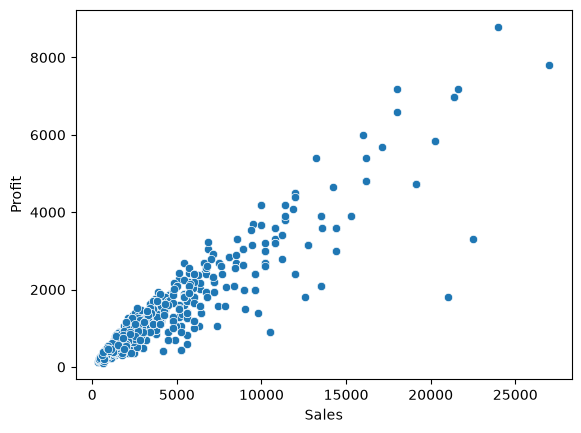

In [69]:

sns.scatterplot(
    data = df,
    x = "Sales",
    y = "Profit"
)

plt.title("Sales Vs Profit")
plt.show()

## 8. Outlier Analysis

The Interquartile Range (IQR) method is used to identify potential outliers in sales and profit values. These records are reviewed as potential high-value business transactions rather than being automatically removed.

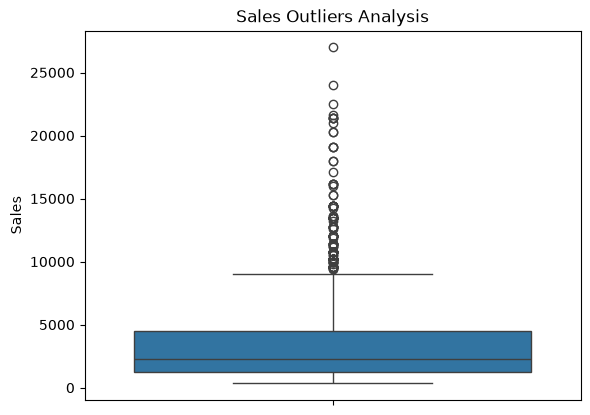

In [20]:
sns.boxplot(data=df["Sales"]
   
)

plt.title("Sales Outliers Analysis")
plt.show()
    


In [11]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 1274.15
Q3: 4498.2
IQR: 3224.0499999999997
Lower Limit: -3561.9249999999997
Upper Limit: 9334.275


In [13]:
Sales_outliers = df[df["Sales"] > upper_limit]
print("Number of Sales Outliers:",len(Sales_outliers))

Number of Sales Outliers: 122


In [16]:
Sales_outliers[["Order_ID", "Product", "Category", "Sales", "Profit"]].sort_values(
    "Sales", ascending=False
).head(10)

,Order_ID,Product,Category,Sales,Profit
1105,ORD100925,Office Chair,Furniture,26996.40,7796.40
133,ORD100343,Air Fryer,Home & Kitchen,23996.00,8796.00
1333,ORD100657,Office Chair,Furniture,22497.00,3297.00
918,ORD100927,Study Table,Furniture,21596.40,7196.40
290,ORD100847,Office Chair,Furniture,21372.15,6972.15
87,ORD101256,Office Chair,Furniture,21372.15,6972.15
395,ORD101569,Office Chair,Furniture,21372.15,6972.15
325,ORD101464,Office Chair,Furniture,21372.15,6972.15
231,ORD100238,Office Chair,Furniture,20997.20,1797.20
356,ORD101466,Office Chair,Furniture,20247.30,5847.30


In [19]:
Sales_outliers["Category"].value_counts()

Category
Furniture         58
Home & Kitchen    43
Electronics       20
Footwear           1
Name: count, dtype: int64

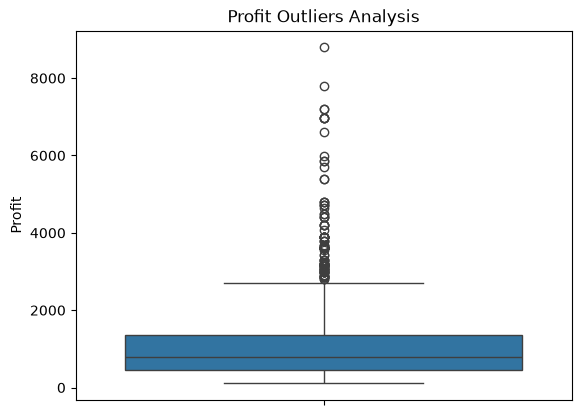

In [21]:
sns.boxplot(data=df["Profit"]
   
)

plt.title("Profit Outliers Analysis")
plt.show()

In [24]:
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 459.15
Q3: 1362.45
IQR: 903.3000000000001
Lower Limit: -895.8000000000001
Upper Limit: 2717.4


In [26]:
Profit_outliers = df[df["Profit"] > upper_limit]

print("Number of Profit Outliers:", len(Profit_outliers))

Number of Profit Outliers: 106


In [28]:
Profit_outliers[["Order_ID", "Product", "Category", "Sales", "Profit"]].sort_values(
    "Profit", ascending=False
).head(10)

,Order_ID,Product,Category,Sales,Profit
133,ORD100343,Air Fryer,Home & Kitchen,23996.00,8796.00
1105,ORD100925,Office Chair,Furniture,26996.40,7796.40
1031,ORD100447,Study Table,Furniture,17997.00,7197.00
918,ORD100927,Study Table,Furniture,21596.40,7196.40
395,ORD101569,Office Chair,Furniture,21372.15,6972.15
87,ORD101256,Office Chair,Furniture,21372.15,6972.15
290,ORD100847,Office Chair,Furniture,21372.15,6972.15
325,ORD101464,Office Chair,Furniture,21372.15,6972.15
895,ORD100273,Air Fryer,Home & Kitchen,17997.00,6597.00
816,ORD100940,Smart Watch,Electronics,15996.00,5996.00


In [30]:
Profit_outliers["Category"].value_counts()

Category
Furniture         44
Home & Kitchen    28
Electronics       21
Footwear          11
Accessories        1
Fashion            1
Name: count, dtype: int64

In [35]:
df["Month"] = df["Order_Date"].dt.month_name()
df[["Order_Date", "Month"]].head()

,Order_Date,Month
0,2026-08-13,August
1,2026-08-14,August
2,2026-08-15,August
3,2026-08-16,August
4,2026-08-17,August


## 9. Monthly / Time Analysis

Monthly sales and profit trends are analyzed to identify seasonal patterns, high-performing months and periods with relatively lower performance.

In [41]:
df["Month_Number"] = df["Order_Date"].dt.month
monthly_analysis = df.groupby(
    ["Month_Number", "Month"]
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).sort_index()

monthly_analysis

,,Total_Sales,Total_Profit
Month_Number,Month,,
1,January,479217.25,153677.25
2,February,479586.05,158166.05
3,March,547698.15,174518.15
4,April,477484.20,150784.20
5,May,507372.95,171722.95
6,June,490597.40,161827.40
7,July,451411.00,150411.00
8,August,450945.80,144465.80
9,September,493983.90,160523.90


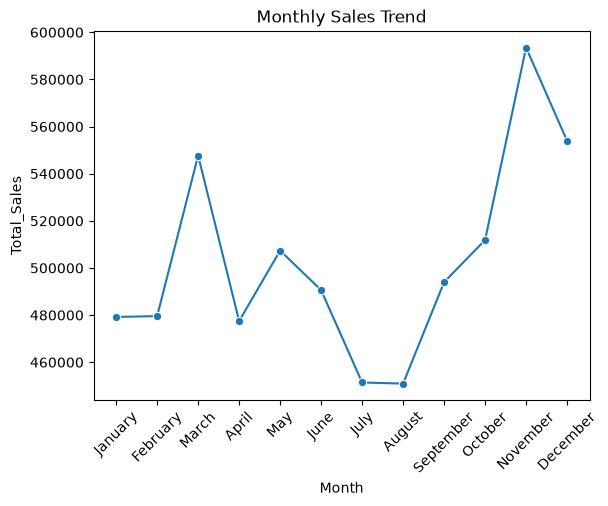

In [44]:
sns.lineplot(
    data=monthly_analysis,
    x="Month",
    y="Total_Sales",
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

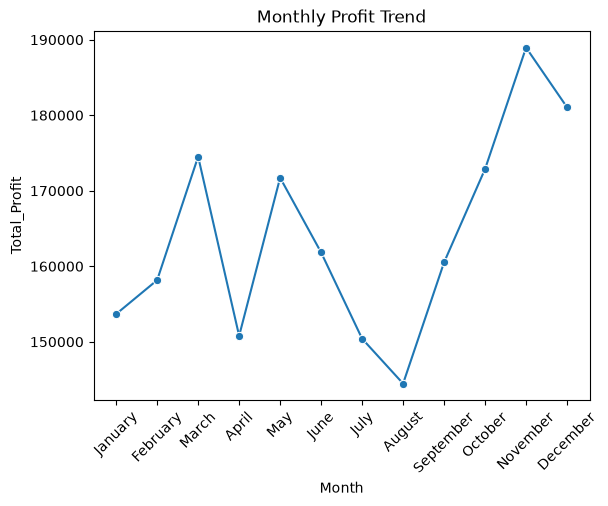

In [46]:
sns.lineplot(
    data=monthly_analysis,
    x="Month",
    y="Total_Profit",
    marker="o"
)
plt.title("Monthly Profit Trend")
plt.xticks(rotation=45)
plt.show()

## 10. Order Status Analysis

Order performance is analyzed based on delivery, return and cancellation status to understand order outcomes and identify potential operational issues.

In [48]:
status_count = df["Order_Status"].value_counts()

status_count

Order_Status
Delivered    1494
Returned      179
Cancelled     127
Name: count, dtype: int64

In [50]:
status_analysis = df.groupby("Order_Status").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
)

status_analysis

,Total_Sales,Total_Profit,Total_Quantity
Order_Status,,,
Cancelled,423154.15,133514.15,194
Delivered,4974705.80,1637275.80,2282
Returned,639770.75,198200.75,261


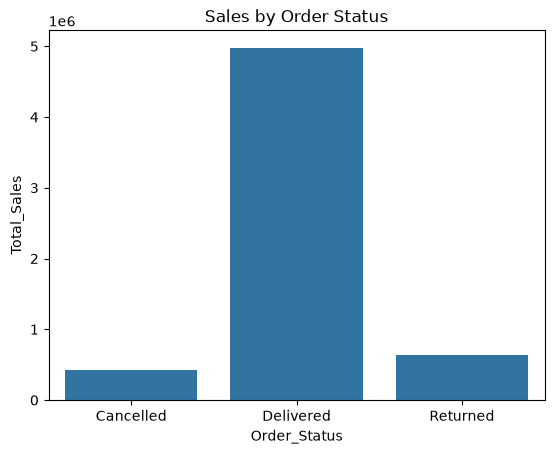

In [52]:
sns.barplot(
    data=status_analysis.reset_index(),
    x="Order_Status",
    y="Total_Sales"
)

plt.title("Sales by Order Status")
plt.show()

In [54]:
total_orders = len(df)

returned_orders = (df["Order_Status"] == "Returned").sum()
cancelled_orders = (df["Order_Status"] == "Cancelled").sum()

return_rate = returned_orders / total_orders * 100
cancel_rate = cancelled_orders / total_orders * 100

print("Return Rate:", round(return_rate, 2), "%")
print("Cancellation Rate:", round(cancel_rate, 2), "%")

Return Rate: 9.94 %
Cancellation Rate: 7.06 %


## 11. Payment Method Analysis

Sales, profit and quantity are compared across different payment methods to understand customer payment preferences and their contribution to business performance.

In [56]:
payment_count = df["Payment_Method"].value_counts()

payment_count

Payment_Method
UPI                 368
Debit Card          366
Net Banking         365
Cash On Delivery    355
Credit Card         346
Name: count, dtype: int64

In [58]:
payment_analysis = df.groupby("Payment_Method").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
)

payment_analysis

,Total_Sales,Total_Profit,Total_Quantity
Payment_Method,,,
Cash On Delivery,1139441.85,370961.85,531
Credit Card,1131596.95,375696.95,520
Debit Card,1232550.85,402030.85,573
Net Banking,1312626.05,426916.05,563
UPI,1221415.00,393385.00,550


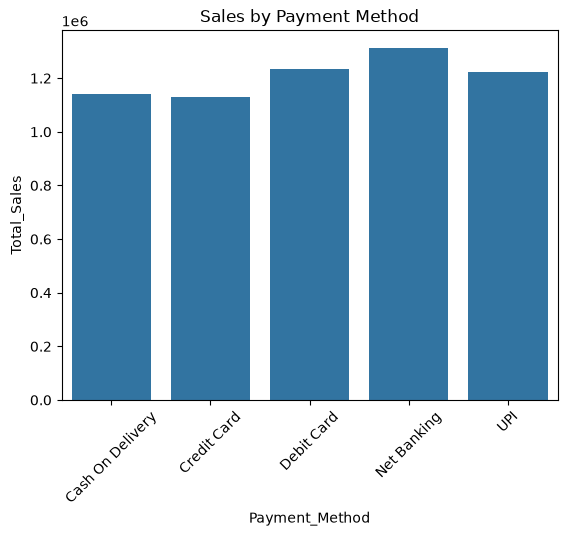

In [62]:
sns.barplot(
    data=payment_analysis.reset_index(),
    x="Payment_Method",
    y="Total_Sales"
)

plt.title("Sales by Payment Method")
plt.xticks(rotation=45)
plt.show()

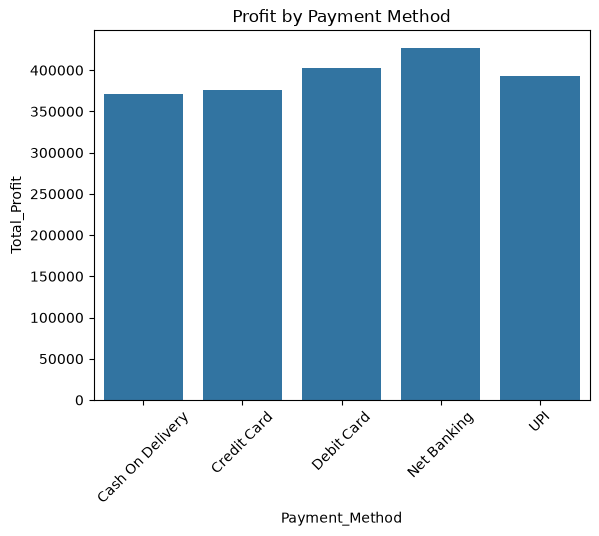

In [64]:
sns.barplot(
    data=payment_analysis.reset_index(),
    x="Payment_Method",
    y="Total_Profit"
)

plt.title("Profit by Payment Method")
plt.xticks(rotation=45)
plt.show()

## 12. City Analysis

City-level analysis is performed to compare sales, profit and order volume across different cities and identify high-performing markets.

In [66]:
city_count = df["City"].value_counts()

city_count.head(10)

City
Bengaluru    163
Kolkata      142
Hyderabad    138
Chennai      131
Ahmedabad    126
Mumbai       124
Indore       123
Lucknow      122
Jaipur       117
Pune         113
Name: count, dtype: int64

In [68]:
city_analysis = df.groupby("City").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

city_analysis.head(10)

,Total_Sales,Total_Profit,Total_Quantity
City,,,
Bengaluru,517917.55,168717.55,233
Hyderabad,479992.95,158682.95,221
Kolkata,466035.20,152085.20,208
Indore,441599.90,146319.90,200
Lucknow,432561.10,136821.10,198
Chennai,427619.60,134339.60,193
Mumbai,413586.70,125196.70,185
Chandigarh,399561.60,131081.60,175
Pune,389097.70,122967.70,171


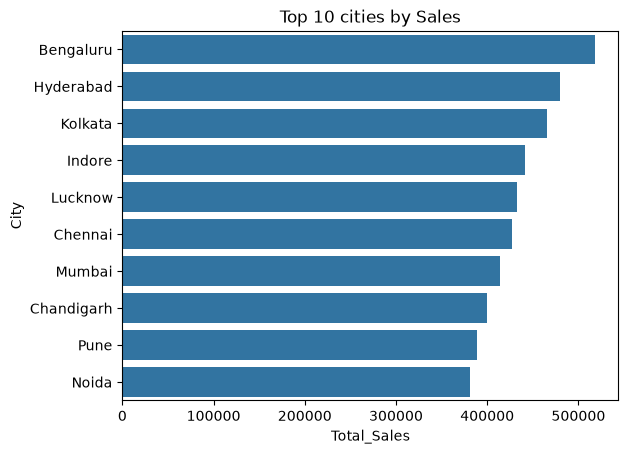

In [70]:
sns.barplot(
    data=city_analysis.head(10).reset_index(),
    x="Total_Sales",
    y="City"
)
plt.title("Top 10 cities by Sales")
plt.show()


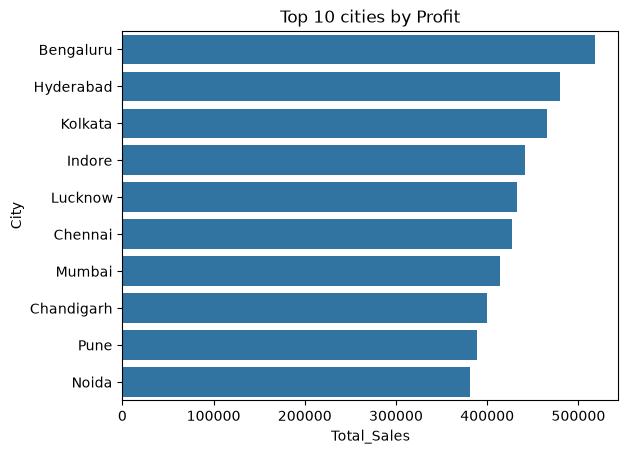

In [72]:
sns.barplot(
    data=city_analysis.head(10).reset_index(),
    x="Total_Sales",
    y="City"
)

plt.title("Top 10 cities by Profit")
plt.show()

## 13. Customer Analysis

Customer-level analysis is performed to understand order frequency, sales contribution, profitability and Average Order Value (AOV).

In [74]:
customer_orders = df["Customer_Name"].value_counts()

customer_orders.head(10)

Customer_Name
Pooja Malhotra    37
Kavya Jain        28
Mohit Gupta       26
Pooja Chauhan     25
Rahul Verma       25
Sneha Singh       24
Kavya Kumar       24
Priya Verma       23
Arjun Chauhan     23
Priya Sharma      22
Name: count, dtype: int64

In [76]:
customer_analysis = df.groupby("Customer_Name").agg(
    Total_Orders=("Order_ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).sort_values("Total_Sales", ascending=False)

customer_analysis.head(10)

,Total_Orders,Total_Sales,Total_Profit
Customer_Name,,,
Pooja Malhotra,37,129653.30,42313.30
Rahul Verma,25,117007.45,37007.45
Kavya Jain,28,100324.95,30904.95
Mohit Gupta,26,99712.85,32932.85
Priya Sharma,22,87300.55,28230.55
Arjun Malhotra,14,83745.30,21685.30
Sneha Singh,24,83053.95,25203.95
Nisha Yadav,21,81891.75,26151.75
Ankit Chauhan,19,80559.35,23109.35


In [78]:
customer_analysis["AOV"] = (
    customer_analysis["Total_Sales"] /
    customer_analysis["Total_Orders"]
)

customer_analysis.sort_values(
    "AOV",
    ascending=False
).head(10)

,Total_Orders,Total_Sales,Total_Profit,AOV
Customer_Name,,,,
Aditya Kumar,5,32521.05,8551.05,6504.210000
Arjun Sharma,4,24344.30,8444.30,6086.075000
Ankit Sharma,1,5999.00,2399.00,5999.000000
Kavya Chauhan,5,29923.20,8933.20,5984.640000
Arjun Malhotra,14,83745.30,21685.30,5981.807143
Riya Malhotra,7,41244.85,13924.85,5892.121429
Mohit Malhotra,7,40080.15,12250.15,5725.735714
Aarav Kumar,8,44998.15,8598.15,5624.768750
Simran Malhotra,4,22314.90,6414.90,5578.725000


## 14. Correlation Analysis

Correlation analysis is used to understand the strength and direction of relationships between numerical variables such as quantity, price, sales, cost and profit.

In [80]:
correlation = df[
    [
        "Quantity",
        "Actual_Price",
        "Discount_Percent",
        "Discounted_Price",
        "Sales",
        "Total_Cost",
        "Profit"
    ]
].corr()

correlation

,Quantity,Actual_Price,Discount_Percent,Discounted_Price,Sales,Total_Cost,Profit
Quantity,1.000000,0.038742,0.011683,0.034456,0.548180,0.511507,0.593049
Actual_Price,0.038742,1.000000,0.037456,0.990155,0.757830,0.781579,0.631752
Discount_Percent,0.011683,0.037456,1.000000,-0.074575,-0.038990,0.047263,-0.253526
Discounted_Price,0.034456,0.990155,-0.074575,1.000000,0.762064,0.770394,0.674576
Sales,0.548180,0.757830,-0.038990,0.762064,1.000000,0.990405,0.937059
Total_Cost,0.511507,0.781579,0.047263,0.770394,0.990405,1.000000,0.879815
Profit,0.593049,0.631752,-0.253526,0.674576,0.937059,0.879815,1.000000


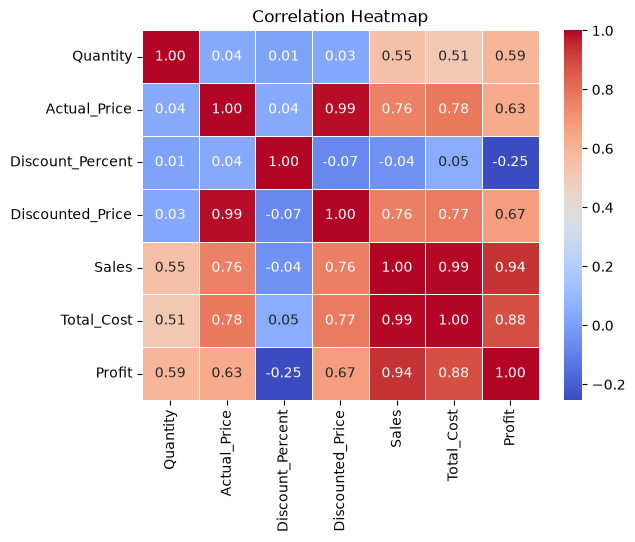

In [82]:
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

In [83]:
# Top business insights

print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Orders:", df["Order_ID"].nunique())
print("Total Quantity:", df["Quantity"].sum())

print("\nHighest Sales Category:")
print(df.groupby("Category")["Sales"].sum().idxmax())

print("\nHighest Profit Category:")
print(df.groupby("Category")["Profit"].sum().idxmax())

print("\nHighest Sales Product:")
print(df.groupby("Product")["Sales"].sum().idxmax())

print("\nHighest Sales City:")
print(df.groupby("City")["Sales"].sum().idxmax())

print("\nHighest Sales Month:")
print(
    df.groupby("Month")["Sales"]
      .sum()
      .idxmax()
)

Total Sales: 6037630.7
Total Profit: 1968990.7
Total Orders: 1800
Total Quantity: 2737

Highest Sales Category:
Electronics

Highest Profit Category:
Electronics

Highest Sales Product:
Office Chair

Highest Sales City:
Bengaluru

Highest Sales Month:
November


## 15. Business Insights

Based on the exploratory analysis, the following key business insights were identified:

1. The dataset generated approximately ₹60.38 lakh in total sales and ₹19.69 lakh in total profit from 1,800 orders.

2. Electronics was the highest-performing category in terms of both sales and total profit.

3. Office Chair generated the highest total sales among the products analyzed.

4. Bengaluru recorded the highest city-level sales.

5. November was the highest-performing month by total sales.

6. Sales and profit showed a strong positive relationship, indicating that higher-sales transactions were generally associated with higher profit in this dataset.

7. The return rate was 9.94%, while the cancellation rate was 7.06%.

8. Outlier analysis identified several high-value sales and profit transactions, particularly in Furniture and Home & Kitchen. These were retained because they may represent genuine high-value business transactions rather than data errors.